<a href="https://colab.research.google.com/github/ranjot-kaur123/pothole_detection_AI/blob/main/AI_POTHOLE_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolo11n.pt")

In [5]:
!ls /content

Pothole.v1-raw.yolov11.zip  runs  sample_data  yolo11n.pt


In [6]:
!unzip -q /content/Pothole.v1-raw.yolov11.zip -d /content/

In [7]:
!ls /content

data.yaml		    README.dataset.txt	 runs	      test   valid
Pothole.v1-raw.yolov11.zip  README.roboflow.txt  sample_data  train  yolo11n.pt


In [8]:
!cat /content/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['pothole']

roboflow:
  workspace: brad-dwyer
  project: pothole-voxrl
  version: 1
  license: ODbL v1.0
  url: https://universe.roboflow.com/brad-dwyer/pothole-voxrl/dataset/1

In [9]:
%%writefile /content/data.yaml

train: /content/train/images
val: /content/valid/images
test: /content/test/images

nc: 1

names:
  0: pothole

Overwriting /content/data.yaml


In [10]:
!ls /content/train/images | head
!ls /content/train/labels | head


img-100_jpg.rf.233751cac3399aa80b5e58a2afbb753a.jpg
img-101_jpg.rf.f213d98946c4f8858a5bf3200c89e39c.jpg
img-102_jpg.rf.16c56ff8f761aec963d9b57aa1b2d3fd.jpg
img-103_jpg.rf.09abf1a8e3477718e143255af3534d29.jpg
img-108_jpg.rf.a35e86abc558a98f252bfc10e49fd6d9.jpg
img-109_jpg.rf.add373710d0d425bd9340c33878e7d42.jpg
img-10_jpg.rf.eaceaaa6f119cf6eb49edc1bc92efaa2.jpg
img-110_jpg.rf.0390f81a2c5b2ad5676a8eb5b043d743.jpg
img-111_jpg.rf.d7e58630e249c45d8c1d564d847dc236.jpg
img-113_jpg.rf.31b41591a5e0c7b0aa02e133e79e1e2a.jpg
img-100_jpg.rf.233751cac3399aa80b5e58a2afbb753a.txt
img-101_jpg.rf.f213d98946c4f8858a5bf3200c89e39c.txt
img-102_jpg.rf.16c56ff8f761aec963d9b57aa1b2d3fd.txt
img-103_jpg.rf.09abf1a8e3477718e143255af3534d29.txt
img-108_jpg.rf.a35e86abc558a98f252bfc10e49fd6d9.txt
img-109_jpg.rf.add373710d0d425bd9340c33878e7d42.txt
img-10_jpg.rf.eaceaaa6f119cf6eb49edc1bc92efaa2.txt
img-110_jpg.rf.0390f81a2c5b2ad5676a8eb5b043d743.txt
img-111_jpg.rf.d7e58630e249c45d8c1d564d847dc236.txt
img-113_jpg.rf

In [11]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [12]:
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

In [13]:
!ls /content

data.yaml		    README.dataset.txt	 sample_data  valid
detect_road_1.webp	    README.roboflow.txt  test	      yolo11n.pt
Pothole.v1-raw.yolov11.zip  runs		 train	      yolo26n.pt


In [14]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# Predict on the uploaded image
results = model.predict(
    source="/content/detect_road_1.webp",
    conf=0.25,
    save=True,
    show_labels=True,
    show_conf=True
)


image 1/1 /content/detect_road_1.webp: 448x640 3 potholes, 52.7ms
Speed: 2.2ms preprocess, 52.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/predict/detect_road_1.webp")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 290ms
Prepared 1 package in 141ms
Installed 1 package in 5ms
 + pi-heif==1.4.0

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict/detect_road_1.webp'

In [16]:
!find /content/runs/detect -type f

/content/runs/detect/predict/detect_road_1.jpg
/content/runs/detect/train/args.yaml
/content/runs/detect/train-2/val_batch1_pred.jpg
/content/runs/detect/train-2/train_batch1201.jpg
/content/runs/detect/train-2/args.yaml
/content/runs/detect/train-2/results.png
/content/runs/detect/train-2/train_batch1200.jpg
/content/runs/detect/train-2/BoxR_curve.png
/content/runs/detect/train-2/weights/best.pt
/content/runs/detect/train-2/weights/last.pt
/content/runs/detect/train-2/train_batch2.jpg
/content/runs/detect/train-2/BoxF1_curve.png
/content/runs/detect/train-2/labels.jpg
/content/runs/detect/train-2/val_batch0_labels.jpg
/content/runs/detect/train-2/val_batch1_labels.jpg
/content/runs/detect/train-2/val_batch0_pred.jpg
/content/runs/detect/train-2/confusion_matrix_normalized.png
/content/runs/detect/train-2/BoxP_curve.png
/content/runs/detect/train-2/val_batch2_pred.jpg
/content/runs/detect/train-2/train_batch1202.jpg
/content/runs/detect/train-2/val_batch2_labels.jpg
/content/runs/detec

In [17]:
!ls -R /content/runs/detect

/content/runs/detect:
predict  train	train-2

/content/runs/detect/predict:
detect_road_1.jpg

/content/runs/detect/train:
args.yaml  weights

/content/runs/detect/train/weights:

/content/runs/detect/train-2:
args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1200.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1201.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1202.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg

/content/runs/detect/train-2/weights:
best.pt  last.pt


['/content/runs/detect/predict/detect_road_1.jpg']


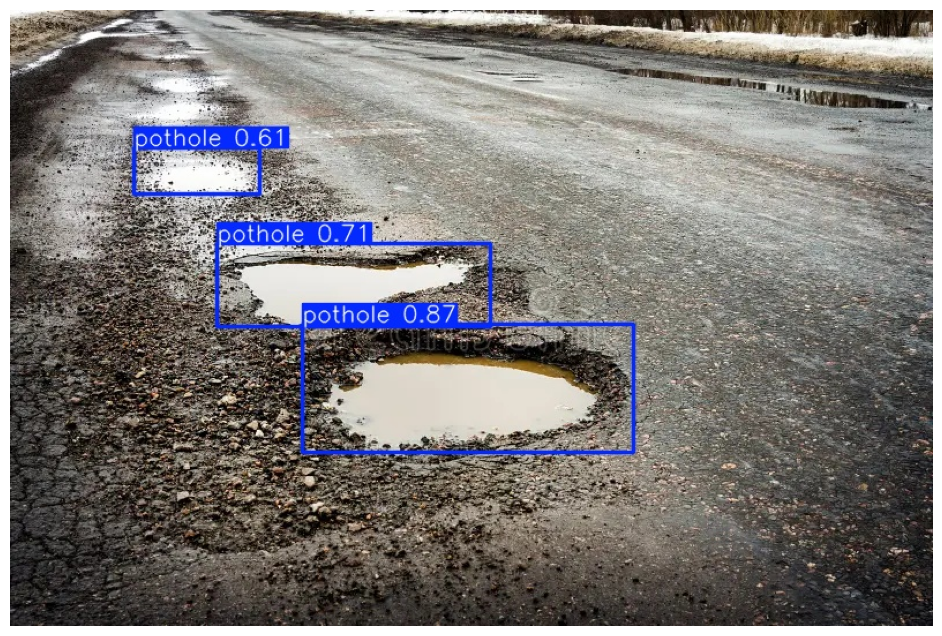

In [18]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

files = glob.glob("/content/runs/detect/predict/*")

print(files)

img = Image.open(files[0])

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [19]:
!ls -R /content/runs/detect

/content/runs/detect:
predict  train	train-2

/content/runs/detect/predict:
detect_road_1.jpg

/content/runs/detect/train:
args.yaml  weights

/content/runs/detect/train/weights:

/content/runs/detect/train-2:
args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1200.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1201.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1202.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg

/content/runs/detect/train-2/weights:
best.pt  last.pt


In [20]:
!git config --global user.email "ranjotk.bt.23@nitj.ac.in"
!git config --global user.name "ranjot-kaur123"